In [1]:
import pandas as pd

# Step 1: download the FD001 training file directly from a verified GitHub mirror of NASA's data
!wget -q https://raw.githubusercontent.com/edwardzjl/CMAPSSData/master/train_FD001.txt

# Step 2: define column names ourselves, since the file has none
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Step 3: load it — sep='\s+' handles NASA's inconsistent spacing
train_fd001 = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)

train_fd001.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# Basic shape and structure
print("Shape:", train_fd001.shape)
print("\nUnique engines:", train_fd001['unit_number'].nunique())

# Missing values check
print("\nMissing values:\n", train_fd001.isnull().sum().sum())

# How many cycles did each engine run before the data stops?
cycles_per_engine = train_fd001.groupby('unit_number')['time_cycles'].max()
print("\nMin cycles run:", cycles_per_engine.min())
print("Max cycles run:", cycles_per_engine.max())
print("Average cycles run:", cycles_per_engine.mean().round(1))

# Sensor variance check — this is the important one
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_std = train_fd001[sensor_cols].std().sort_values()
print("\nSensor standard deviations (lowest = most constant):\n", sensor_std)

Shape: (20631, 26)

Unique engines: 100

Missing values:
 0

Min cycles run: 128
Max cycles run: 362
Average cycles run: 206.3

Sensor standard deviations (lowest = most constant):
 sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


In [3]:
train_fd001['max_cycle'] = train_fd001.groupby('unit_number')['time_cycles'].transform('max')
train_fd001['RUL'] = train_fd001['max_cycle'] - train_fd001['time_cycles']


In [4]:
train_fd001[['unit_number', 'time_cycles', 'max_cycle', 'RUL']].head(10)

,unit_number,time_cycles,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [5]:
train_fd001['RUL'] = train_fd001['RUL'].clip(lower=0, upper=125)

In [6]:
train_fd001[['unit_number', 'time_cycles', 'RUL']].head(10)

,unit_number,time_cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


In [7]:

train_fd001[['unit_number', 'time_cycles', 'RUL']].tail(10)

,unit_number,time_cycles,RUL
20621,100,191,9
20622,100,192,8
20623,100,193,7
20624,100,194,6
20625,100,195,5
20626,100,196,4
20627,100,197,3
20628,100,198,2
20629,100,199,1
20630,100,200,0


In [8]:
dead_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
train_fd001 = train_fd001.drop(columns=dead_sensors)

In [9]:
train_fd001 = train_fd001.drop(columns=['max_cycle'])
train_fd001.columns.tolist()

['unit_number',
 'time_cycles',
 'setting_1',
 'setting_2',
 'setting_3',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21',
 'RUL']

In [10]:
train_fd001['sensor_9_rollavg'] = train_fd001.groupby('unit_number')['sensor_9'].rolling(window=5).mean().reset_index(level=0, drop=True)

In [11]:
train_fd001[['unit_number', 'time_cycles', 'sensor_9', 'sensor_9_rollavg']].head(10)

,unit_number,time_cycles,sensor_9,sensor_9_rollavg
0,1,1,9046.19,NaN
1,1,2,9044.07,NaN
2,1,3,9052.94,NaN
3,1,4,9049.48,NaN
4,1,5,9055.15,9049.566
5,1,6,9049.68,9050.264
6,1,7,9059.13,9053.276
7,1,8,9040.80,9050.848
8,1,9,9046.46,9050.244
9,1,10,9051.70,9049.554


In [12]:
print("sensor_9".startswith("sensor_"))
print("unit_number".startswith("sensor_"))

True
False


In [13]:
sensor_cols_clean = [col for col in train_fd001.columns if col.startswith('sensor_')]
print(sensor_cols_clean)

['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_9_rollavg']


In [14]:
sensor_cols_clean = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
                      'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
                      'sensor_17', 'sensor_20', 'sensor_21']
print(len(sensor_cols_clean))

14


In [15]:
for sensor in sensor_cols_clean:
  train_fd001[sensor + '_rollavg'] = train_fd001.groupby('unit_number')[sensor].rolling(window=5).mean().reset_index(level=0, drop=True)
print(train_fd001.shape)

(20631, 34)


In [16]:
print([col for col in train_fd001.columns if 'rollavg' in col])

['sensor_9_rollavg', 'sensor_2_rollavg', 'sensor_3_rollavg', 'sensor_4_rollavg', 'sensor_7_rollavg', 'sensor_8_rollavg', 'sensor_11_rollavg', 'sensor_12_rollavg', 'sensor_13_rollavg', 'sensor_14_rollavg', 'sensor_15_rollavg', 'sensor_17_rollavg', 'sensor_20_rollavg', 'sensor_21_rollavg']


In [17]:
import numpy as np

def get_slope(values):
  x = np.arange(len(values))
  slope = np.polyfit(x, values, 1)[0]
  return slope

In [18]:
test_values = [9048, 9049, 9050, 9051, 9052]
print(get_slope(test_values))

0.9999999999990076


In [19]:
for sensor in sensor_cols_clean:
    train_fd001[sensor + '_slope'] = train_fd001.groupby('unit_number')[sensor].rolling(window=5).apply(get_slope).reset_index(level=0, drop=True)

In [20]:
print(train_fd001.shape)

(20631, 48)


In [21]:
print([col for col in train_fd001.columns if 'slope' in col])

['sensor_2_slope', 'sensor_3_slope', 'sensor_4_slope', 'sensor_7_slope', 'sensor_8_slope', 'sensor_9_slope', 'sensor_11_slope', 'sensor_12_slope', 'sensor_13_slope', 'sensor_14_slope', 'sensor_15_slope', 'sensor_17_slope', 'sensor_20_slope', 'sensor_21_slope']


In [22]:
print(train_fd001.isnull().sum().sum())
print(train_fd001[train_fd001['sensor_9_rollavg'].isnull()].shape[0])

11200
400


In [23]:
train_fd001_clean= train_fd001.dropna()
print(train_fd001_clean.shape)
print(train_fd001_clean.isnull().sum().sum())

(20231, 48)
0


In [24]:
import numpy as np

all_engines = train_fd001_clean['unit_number'].unique()
print(len(all_engines))

100


In [25]:
np.random.seed(42)
shuffled_engines = np.random.permutation(all_engines)

train_engines = shuffled_engines[:80]
test_engines = shuffled_engines[80:]

print(len(train_engines), len(test_engines))

80 20


In [26]:
train_data = train_fd001_clean[train_fd001_clean['unit_number'].isin(train_engines)]
test_data = train_fd001_clean[train_fd001_clean['unit_number'].isin(test_engines)]

print(train_data.shape)
print(test_data.shape)

(16020, 48)
(4211, 48)


In [27]:
setting_std = train_fd001_clean[setting_names].std().sort_values()
print(setting_std)

setting_3    0.000000
setting_2    0.000293
setting_1    0.002189
dtype: float64


In [28]:
train_fd001_clean = train_fd001_clean.drop(columns=['setting_1', 'setting_2', 'setting_3'])

In [29]:
print(train_fd001_clean.shape)
print(train_fd001_clean.columns.tolist())

(20231, 45)
['unit_number', 'time_cycles', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL', 'sensor_9_rollavg', 'sensor_2_rollavg', 'sensor_3_rollavg', 'sensor_4_rollavg', 'sensor_7_rollavg', 'sensor_8_rollavg', 'sensor_11_rollavg', 'sensor_12_rollavg', 'sensor_13_rollavg', 'sensor_14_rollavg', 'sensor_15_rollavg', 'sensor_17_rollavg', 'sensor_20_rollavg', 'sensor_21_rollavg', 'sensor_2_slope', 'sensor_3_slope', 'sensor_4_slope', 'sensor_7_slope', 'sensor_8_slope', 'sensor_9_slope', 'sensor_11_slope', 'sensor_12_slope', 'sensor_13_slope', 'sensor_14_slope', 'sensor_15_slope', 'sensor_17_slope', 'sensor_20_slope', 'sensor_21_slope']


In [30]:
train_data = train_fd001_clean[train_fd001_clean['unit_number'].isin(train_engines)]
test_data = train_fd001_clean[train_fd001_clean['unit_number'].isin(test_engines)]



In [31]:
print(train_data.shape)
print(test_data.shape)

(16020, 45)
(4211, 45)


In [32]:
X_train = train_data.drop(columns=['RUL', 'unit_number'])
y_train = train_data['RUL']

X_test = test_data.drop(columns=['RUL', 'unit_number'])
y_test = test_data['RUL']

In [33]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(16020, 43) (16020,)
(4211, 43) (4211,)


In [34]:
train_data.to_csv('train_data_engineered.csv', index=False)
test_data.to_csv('test_data_engineered.csv', index=False)

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [36]:
y_pred_lr = lr.predict(X_test)

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 16.393922218874195
MSE: 403.221635649928
R2: 0.7669766349046648


In [38]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

xgb_model = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)



MAE: 12.396927833557129
MSE: 306.91131591796875
R2: 0.822634756565094


In [39]:
y_pred_lr = lr.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

print("Linear Regression — MAE:", mean_absolute_error(y_test, y_pred_lr), "| R2:", r2_score(y_test, y_pred_lr))
print("XGBoost — MAE:", mean_absolute_error(y_test, y_pred_xgb), "| R2:", r2_score(y_test, y_pred_xgb))

Linear Regression — MAE: 16.393922218874195 | R2: 0.7669766349046648
XGBoost — MAE: 12.396927833557129 | R2: 0.822634756565094


In [40]:
y_pred_train = xgb_model.predict(X_train)

print("Train — MAE:", mean_absolute_error(y_train, y_pred_train), "| R2:", r2_score(y_train, y_pred_train))
print("Test  — MAE:", mean_absolute_error(y_test, y_pred_xgb), "| R2:", r2_score(y_test, y_pred_xgb))

Train — MAE: 8.004556655883789 | R2: 0.9224674701690674
Test  — MAE: 12.396927833557129 | R2: 0.822634756565094


In [41]:
from sklearn.model_selection import GroupKFold
import numpy as np

groups = train_data['unit_number']
gkf = GroupKFold(n_splits=5)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups)):
  X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
  y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

  fold_model = XGBRegressor(n_estimators=100, max_depth=4, random_state=43)
  fold_model.fit(X_tr, y_tr)

  fold_pred = fold_model.predict(X_val)
  fold_mae = mean_absolute_error(y_val, fold_pred)
  fold_scores.append(fold_mae)
  print(f"Fold {fold+1} MAE: {fold_mae:.2f}")

print("\nAverage MAE:", np.mean(fold_scores))
print("Std Dev:", np.std(fold_scores))

Fold 1 MAE: 10.43
Fold 2 MAE: 13.92
Fold 3 MAE: 11.13
Fold 4 MAE: 10.88
Fold 5 MAE: 12.34

Average MAE: 11.740116691589355
Std Dev: 1.2577098480060662


In [42]:
def run_cv(n_estimators, max_depth, learning_rate, random_state):
  fold_scores = []

  for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    fold_model = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=random_state)

    fold_model.fit(X_tr, y_tr)
    fold_pred = fold_model.predict(X_val)
    fold_mae = mean_absolute_error(y_val, fold_pred)
    fold_scores.append(fold_mae)

  return np.mean(fold_scores)

In [43]:
baseline_score = run_cv(n_estimators=100, max_depth=4, learning_rate=0.3, random_state=42)
print("Baseline:", baseline_score)

Baseline: 11.740116691589355


In [44]:
def run_cv(n_estimators, max_depth, learning_rate, subsample=1.0, colsample_bytree=1.0):
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        fold_model = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                    learning_rate=learning_rate, subsample=subsample,
                                    colsample_bytree=colsample_bytree, random_state=42)
        fold_model.fit(X_tr, y_tr)

        fold_pred = fold_model.predict(X_val)
        fold_mae = mean_absolute_error(y_val, fold_pred)
        fold_scores.append(fold_mae)

    return np.mean(fold_scores)

In [45]:
tuned_score = run_cv(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8)
print("Tuned:", tuned_score)

Tuned: 11.357583999633789


In [46]:
final_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, random_state=42)
final_model.fit(X_train, y_train)

y_pred_train_final = final_model.predict(X_train)
y_pred_test_final = final_model.predict(X_test)

print("Train — MAE:", mean_absolute_error(y_train, y_pred_train_final))
print("Test  — MAE:", mean_absolute_error(y_test, y_pred_test_final))

Train — MAE: 9.962821960449219
Test  — MAE: 12.24474811553955


In [47]:
from sklearn.preprocessing import StandardScaler

rollavg_slope_cols = [col for col in X_train.columns if 'rollavg' in col or 'slope' in col]
print(len(rollavg_slope_cols))

scaler = StandardScaler()
X_cluster_train = scaler.fit_transform(X_train[rollavg_slope_cols])


28


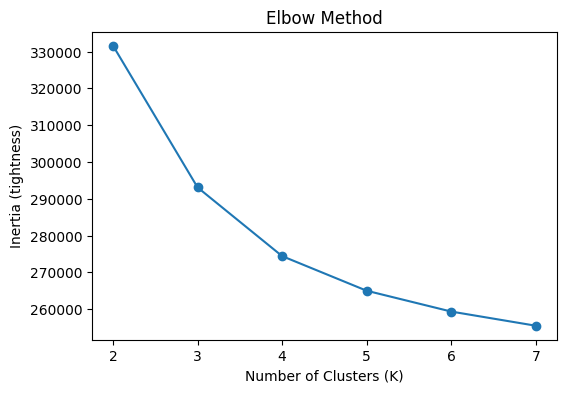

In [48]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []
k_range = range(2,8)

for k in k_range:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(X_cluster_train)
  inertia_values.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel("Inertia (tightness)")
plt.title("Elbow Method")
plt.show()


In [49]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_cluster_train)

X_train['health_cluster'] = train_clusters
print(X_train['health_cluster'].value_counts())

health_cluster
1    6987
2    5738
3    2156
0    1139
Name: count, dtype: int64


In [50]:
X_cluster_test = scaler.transform(X_test[rollavg_slope_cols])
test_clusters = kmeans.predict(X_cluster_test)
X_test['health_cluster'] = test_clusters

In [51]:
print(X_test['health_cluster'].value_counts())

health_cluster
1    1769
2    1639
3     539
0     264
Name: count, dtype: int64


In [52]:
X_train['RUL_check'] = y_train.values
print(X_train.groupby('health_cluster')['RUL_check'].mean())

# Drop 'RUL_check' from X_train to match X_test features for model training/prediction
X_train = X_train.drop(columns=['RUL_check'])

health_cluster
0     18.663740
1     91.950766
2    114.275009
3     24.616419
Name: RUL_check, dtype: float64


In [53]:
final_model_v2 = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42)

final_model_v2.fit(X_train, y_train)

y_pred_test_v2 = final_model_v2.predict(X_test)

print("Test MAE with health_cluster:", mean_absolute_error(y_test, y_pred_test_v2))

Test MAE with health_cluster: 12.234009742736816


/tmp/ipykernel_2628/4140888182.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


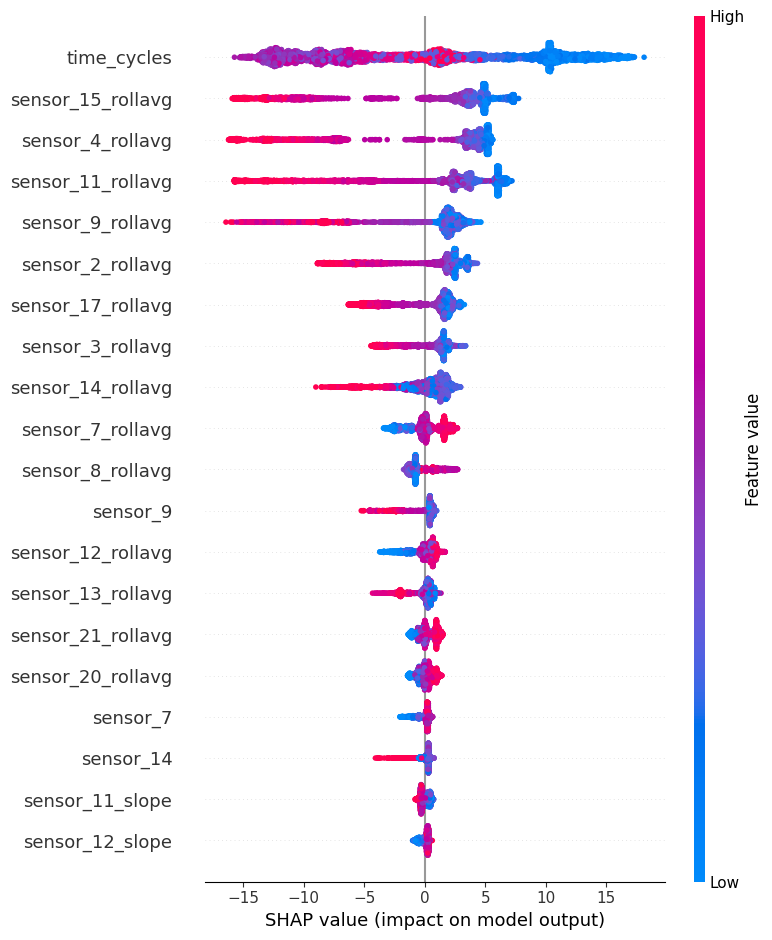

In [54]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(final_model_v2)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

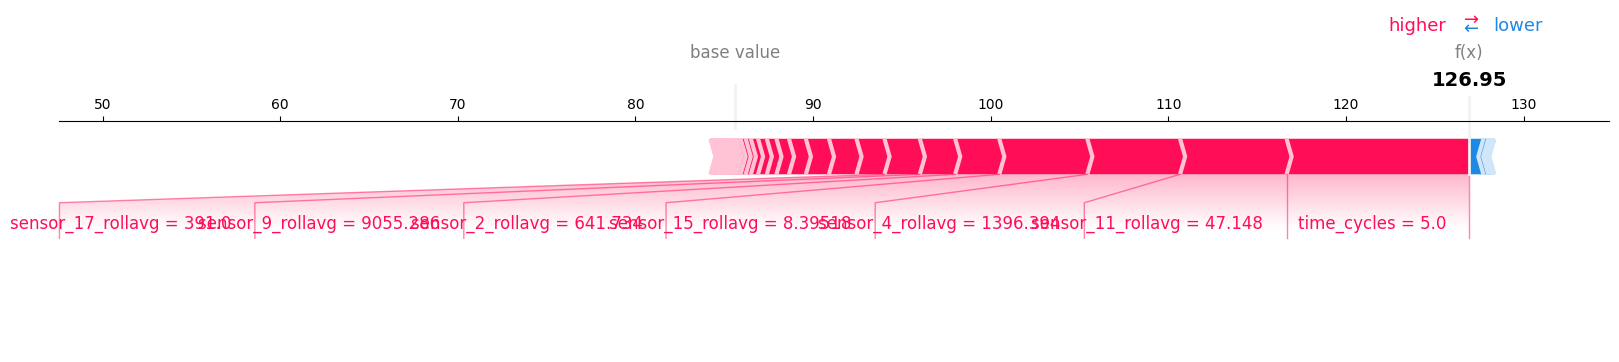

In [55]:
sample_idx = 0

shap.force_plot(explainer.expected_value, shap_values[sample_idx],
                 X_test.iloc[sample_idx], matplotlib=True)

In [56]:
risky_idx = y_pred_test_v2.argmin()
print("Predicted RUL for this engine:", y_pred_test_v2[risky_idx])

Predicted RUL for this engine: 0.0750979


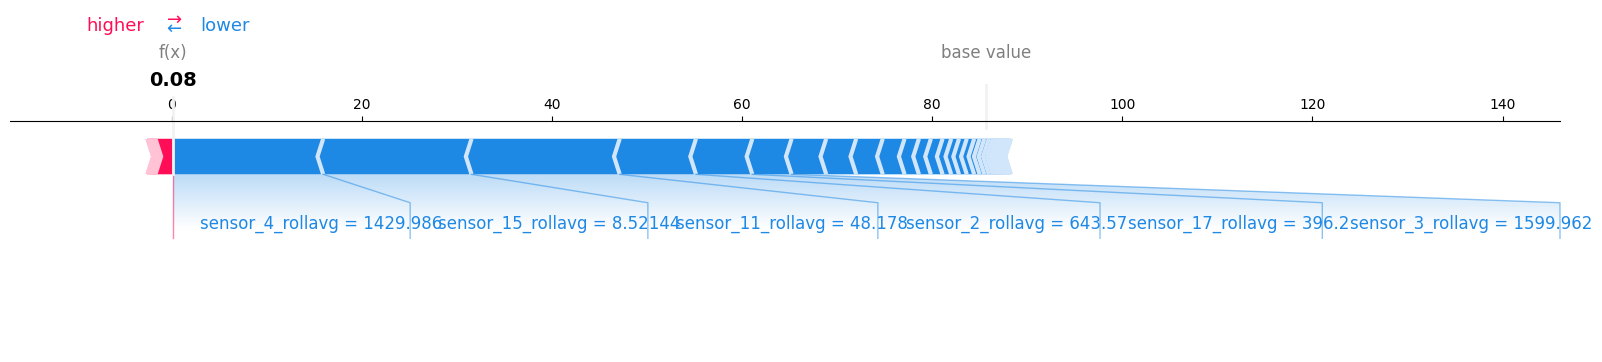

In [57]:
shap.force_plot(explainer.expected_value, shap_values[risky_idx], X_test.iloc[risky_idx], matplotlib=True)

In [58]:
import joblib

joblib.dump(final_model_v2, 'turbineguard_model.pkl')
joblib.dump(scaler, 'turbineguard_scaler.pkl')
joblib.dump(kmeans, 'turbineguard_kmeans.pkl')

print("Saved all 3 files")

Saved all 3 files


In [59]:
%%writefile main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np

app = FastAPI()

model = joblib.load('turbineguard_model.pkl')
scaler = joblib.load('turbineguard_scaler.pkl')
kmeans = joblib.load('turbineguard_kmeans.pkl')

rollavg_slope_cols = [col for col in ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8',
    'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
    'sensor_20', 'sensor_21']]

Writing main.py


In [60]:
joblib.dump(list(X_train.columns), 'feature_columns.pkl')

['feature_columns.pkl']

In [63]:
%%writefile main.py
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Dict
import joblib
import pandas as pd

app = FastAPI()

model = joblib.load('turbineguard_model.pkl')
scaler = joblib.load('turbineguard_scaler.pkl')
kmeans = joblib.load('turbineguard_kmeans.pkl')
feature_columns = joblib.load('feature_columns.pkl')

rollavg_slope_cols = [col for col in feature_columns if 'rollavg' in col or 'slope' in col]

@app.get("/")
def health_check():
    return {"status": "TurbineGuard API is running"}

class EngineReading(BaseModel):
    features: Dict[str, float]

@app.post("/predict")
def predict_rul(reading: EngineReading):
    input_df = pd.DataFrame([reading.features])
    input_df = input_df[feature_columns[:-1]]

    cluster_input = scaler.transform(input_df[rollavg_slope_cols])
    input_df['health_cluster'] = kmeans.predict(cluster_input)[0]
    input_df = input_df[feature_columns]

    predicted_rul = float(model.predict(input_df)[0])

    if predicted_rul < 20:
        risk = "Critical"
    elif predicted_rul < 50:
        risk = "Warning"
    elif predicted_rul < 90:
        risk = "Moderate"
    else:
        risk = "Healthy"

    return {"predicted_RUL": round(predicted_rul, 1), "risk_tier": risk}

Overwriting main.py


In [64]:
from fastapi.testclient import TestClient
from main import app

client = TestClient(app)

sample_input = X_test.iloc[0].drop('health_cluster').to_dict()
response = client.post("/predict", json={"features": sample_input})
print(response.json())

{'predicted_RUL': 126.9, 'risk_tier': 'Healthy'}


In [65]:
%%writefile requirements.txt
fastapi
uvicorn
scikit-learn
xgboost
pandas
numpy
joblib
pydantic

Writing requirements.txt


In [66]:
%%writefile Dockerfile
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
CMD ["sh", "-c", "uvicorn main:app --host 0.0.0.0 --port ${PORT:-8000}"]

Writing Dockerfile


In [67]:
import os, shutil
from google.colab import files

os.makedirs('turbineguard_api', exist_ok=True)

for f in ['main.py', 'requirements.txt', 'Dockerfile', 'turbineguard_model.pkl',
          'turbineguard_scaler.pkl', 'turbineguard_kmeans.pkl', 'feature_columns.pkl']:
    shutil.copy(f, f'turbineguard_api/{f}')

shutil.make_archive('turbineguard_api', 'zip', 'turbineguard_api')
files.download('turbineguard_api.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>